In [1]:
import pandas as pd

df = pd.read_csv('/content/flight_price.csv')

### First 5 rows of the dataset

In [2]:
display(df.head())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,3/22/2026 1:10,2h 50m,non-stop,No info,3897
1,Air India,1/5/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/6/2019,Delhi,Cochin,DEL → LKO → BOM → COK,9:25,6/10/2026 4:25,19h,2 stops,No info,13882
3,IndiGo,12/5/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,1/3/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Shape of the dataset

In [3]:
print(df.shape)

(10683, 11)


### Data types of each column

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


None

### Null value count per column

In [5]:
display(df.isnull().sum())

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


### Data Cleaning Steps

In [6]:
# 1. Drop the 2 rows where Route or Total_Stops is null
df.dropna(subset=['Route', 'Total_Stops'], inplace=True)
print(f"Shape of dataframe after dropping nulls: {df.shape}")

Shape of dataframe after dropping nulls: (10682, 11)


In [7]:
# 2. Convert Date_of_Journey to datetime format
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='mixed')

# 3. Extract day, month from Date_of_Journey as new columns: Journey_Day, Journey_Month
df['Journey_Day'] = df['Date_of_Journey'].dt.day
df['Journey_Month'] = df['Date_of_Journey'].dt.month
print("Converted 'Date_of_Journey' to datetime and extracted 'Journey_Day', 'Journey_Month'.")

Converted 'Date_of_Journey' to datetime and extracted 'Journey_Day', 'Journey_Month'.


In [8]:
# 4. Convert Duration into total minutes as a new column: Duration_mins
def convert_duration_to_minutes(duration):
    if pd.isna(duration): # Handle NaN values if any
        return None
    duration = str(duration).replace(' ', '') # Remove space for easier parsing
    hours = 0
    minutes = 0
    if 'h' in duration:
        h_index = duration.find('h')
        hours = int(duration[:h_index])
        duration = duration[h_index+1:]
    if 'm' in duration:
        m_index = duration.find('m')
        minutes = int(duration[:m_index])
    return hours * 60 + minutes

df['Duration_mins'] = df['Duration'].apply(convert_duration_to_minutes)
print("Converted 'Duration' to 'Duration_mins'.")

Converted 'Duration' to 'Duration_mins'.


In [9]:
# 5. Map Total_Stops to numbers
stops_mapping = {
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
}
df['Total_Stops'] = df['Total_Stops'].map(stops_mapping).astype(int)
print("Mapped 'Total_Stops' to numerical values.")

Mapped 'Total_Stops' to numerical values.


In [10]:
# 6. Extract hour from Dep_Time and Arrival_Time as: Dep_Hour, Arrival_Hour
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time'], format='mixed').dt.hour
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time'], format='mixed').dt.hour
print("Extracted 'Dep_Hour' and 'Arrival_Hour'.")

Extracted 'Dep_Hour' and 'Arrival_Hour'.


### Updated DataFrame: First 5 rows and Data Types

In [11]:
display(df.head())
display(df.info())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Duration_mins,Dep_Hour,Arrival_Hour
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,3/22/2026 1:10,2h 50m,0,No info,3897,24,3,170,22,1
1,Air India,2019-01-05,Kolkata,Banglore,CCU → IXR → BBI → BLR,5:50,13:15,7h 25m,2,No info,7662,5,1,445,5,13
2,Jet Airways,2019-09-06,Delhi,Cochin,DEL → LKO → BOM → COK,9:25,6/10/2026 4:25,19h,2,No info,13882,6,9,1140,9,4
3,IndiGo,2019-12-05,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,5,12,325,18,23
4,IndiGo,2019-01-03,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,3,1,285,16,21


<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Dep_Time         10682 non-null  object        
 6   Arrival_Time     10682 non-null  object        
 7   Duration         10682 non-null  object        
 8   Total_Stops      10682 non-null  int64         
 9   Additional_Info  10682 non-null  object        
 10  Price            10682 non-null  int64         
 11  Journey_Day      10682 non-null  int32         
 12  Journey_Month    10682 non-null  int32         
 13  Duration_mins    10682 non-null  int64         
 14  Dep_Hour         10682 non-null  int32     

None

### Verification of Cleaning Steps

In [12]:
# 1. Value counts of Total_Stops
display(df['Total_Stops'].value_counts())

,count
Total_Stops,
1,5625
0,3491
2,1520
3,45
4,1


In [13]:
# 2. Min, max, mean of Duration_mins
print(f"Duration_mins - Min: {df['Duration_mins'].min()}, Max: {df['Duration_mins'].max()}, Mean: {df['Duration_mins'].mean():.2f}")

Duration_mins - Min: 5, Max: 2860, Mean: 643.02


In [14]:
# 3. Min, max, mean of Price
print(f"Price - Min: {df['Price'].min()}, Max: {df['Price'].max()}, Mean: {df['Price'].mean():.2f}")

Price - Min: 1759, Max: 79512, Mean: 9087.21


In [15]:
# 4. Unique values in Airline, Source, Destination
print(f"Unique Airlines: {df['Airline'].unique().tolist()}")
print(f"Unique Sources: {df['Source'].unique().tolist()}")
print(f"Unique Destinations: {df['Destination'].unique().tolist()}")

Unique Airlines: ['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet', 'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia', 'Vistara Premium economy', 'Jet Airways Business', 'Multiple carriers Premium economy', 'Trujet']
Unique Sources: ['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Unique Destinations: ['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']


In [16]:
# 5. Value counts of Additional_Info
display(df['Additional_Info'].value_counts())

,count
Additional_Info,
No info,8344
In-flight meal not included,1982
No check-in baggage included,320
1 Long layover,19
Change airports,7
Business class,4
No Info,3
1 Short layover,1
Red-eye flight,1


### Final Cleaning Steps

In [17]:
# 1. In Additional_Info, replace "No Info" with "No info"
df['Additional_Info'] = df['Additional_Info'].str.replace('No Info', 'No info')
print("Replaced 'No Info' with 'No info' in 'Additional_Info' column.")

Replaced 'No Info' with 'No info' in 'Additional_Info' column.


In [18]:
# 2. Drop these columns as they are no longer needed
drop_columns = ['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration', 'Route', 'Additional_Info']
df.drop(columns=drop_columns, inplace=True)
print(f"Dropped columns: {drop_columns}")

Dropped columns: ['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration', 'Route', 'Additional_Info']


### Cleaned DataFrame: Columns, First 5 Rows, and Shape

In [19]:
# 3. Show the final dataframe columns and first 5 rows
print("Final DataFrame Columns:")
display(df.columns.tolist())
display(df.head())

Final DataFrame Columns:


['Airline',
 'Source',
 'Destination',
 'Total_Stops',
 'Price',
 'Journey_Day',
 'Journey_Month',
 'Duration_mins',
 'Dep_Hour',
 'Arrival_Hour']

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Duration_mins,Dep_Hour,Arrival_Hour
0,IndiGo,Banglore,New Delhi,0,3897,24,3,170,22,1
1,Air India,Kolkata,Banglore,2,7662,5,1,445,5,13
2,Jet Airways,Delhi,Cochin,2,13882,6,9,1140,9,4
3,IndiGo,Kolkata,Banglore,1,6218,5,12,325,18,23
4,IndiGo,Banglore,New Delhi,1,13302,3,1,285,16,21


In [20]:
# 4. Also show the shape of the cleaned dataframe
print(f"Shape of the cleaned DataFrame: {df.shape}")

Shape of the cleaned DataFrame: (10682, 10)


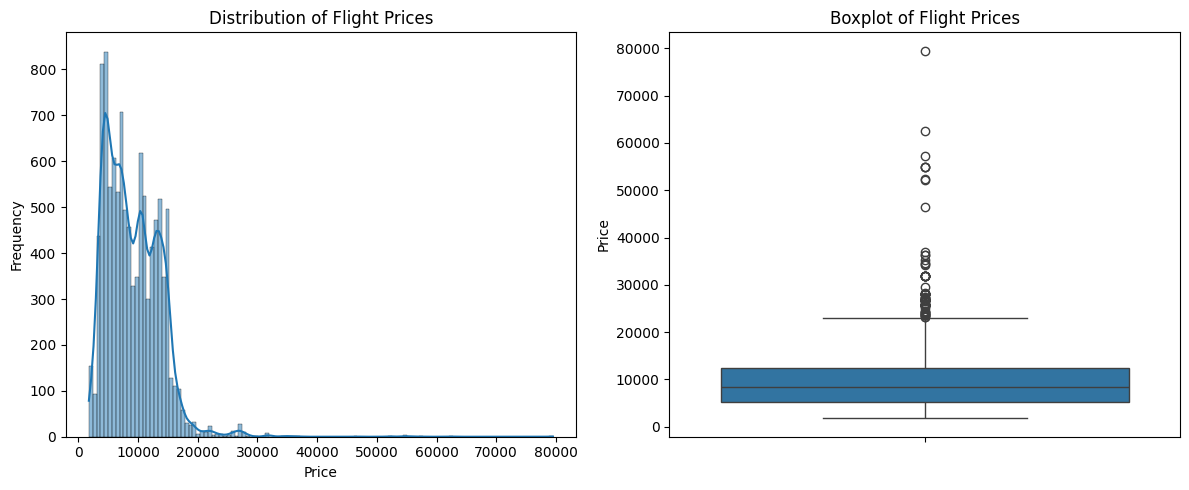

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Histogram of Price
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Boxplot of Price
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['Price'])
plt.title('Boxplot of Flight Prices')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3460/3017138355.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Airline'], order=airline_counts.index, palette='viridis')
/tmp/ipykernel_3460/3017138355.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Price', y='Airline', data=df, order=median_price_per_airline.index, palette='magma')


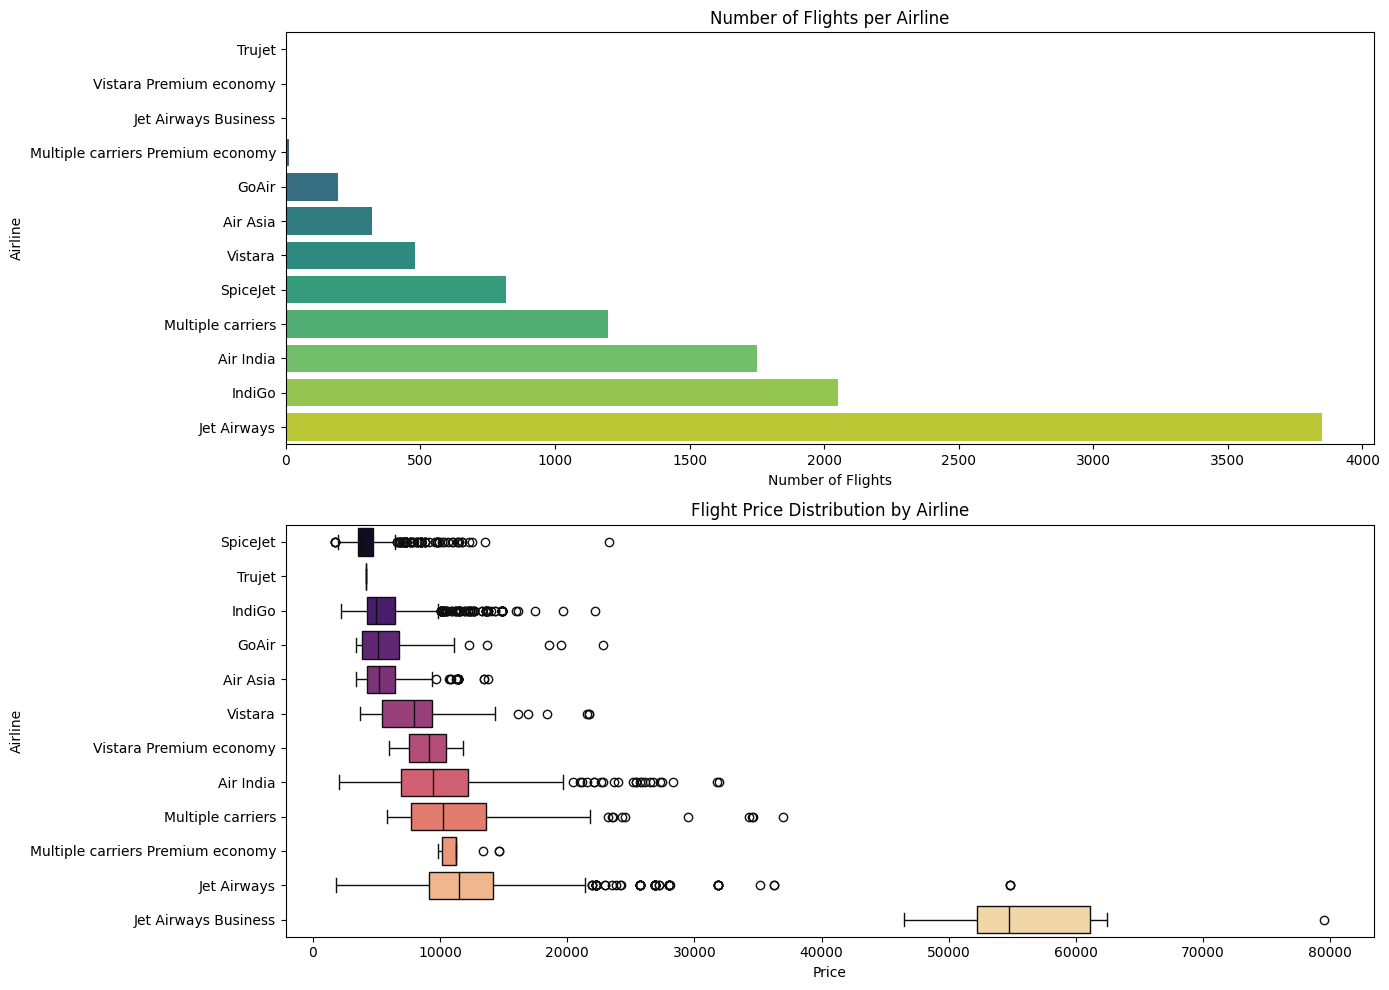

In [22]:
plt.figure(figsize=(14, 10))

# 1. Countplot of Airline (number of flights per airline) - horizontal bar, sorted by count
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
airline_counts = df['Airline'].value_counts().sort_values(ascending=True)
sns.countplot(y=df['Airline'], order=airline_counts.index, palette='viridis')
plt.title('Number of Flights per Airline')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')

# 2. Boxplot of Price vs Airline - horizontal, sorted by median price
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
median_price_per_airline = df.groupby('Airline')['Price'].median().sort_values(ascending=True)
sns.boxplot(x='Price', y='Airline', data=df, order=median_price_per_airline.index, palette='magma')
plt.title('Flight Price Distribution by Airline')
plt.xlabel('Price')
plt.ylabel('Airline')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3460/696865865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Total_Stops', data=df, palette='viridis')
/tmp/ipykernel_3460/696865865.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total_Stops', y='Price', data=df, palette='magma')


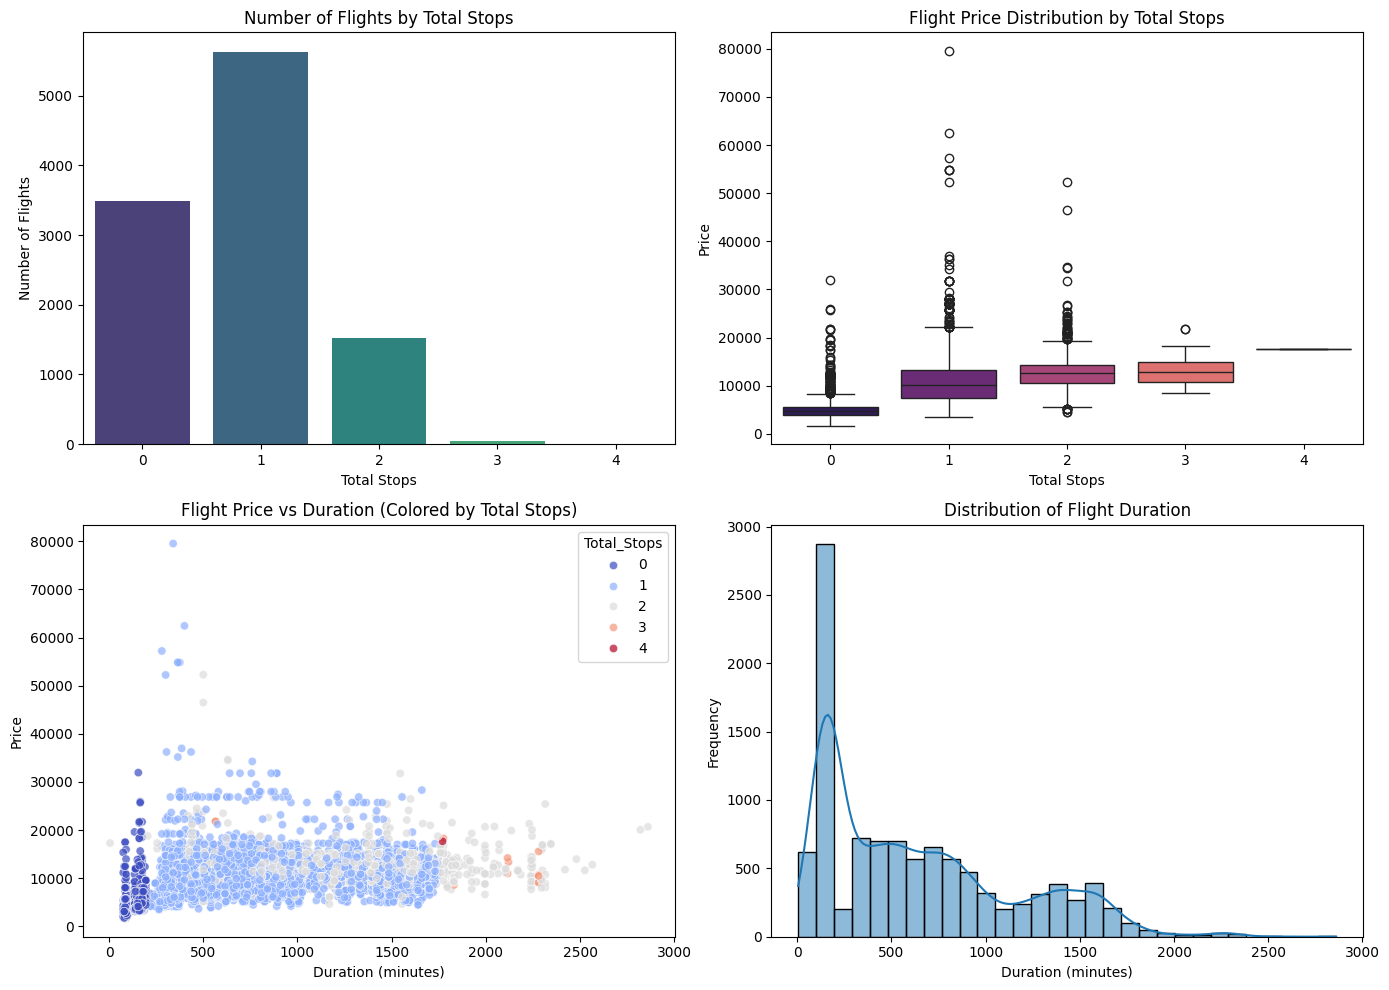

In [23]:
plt.figure(figsize=(14, 10))

# 1. Countplot of Total_Stops
plt.subplot(2, 2, 1) # 2 rows, 2 columns, first plot
sns.countplot(x='Total_Stops', data=df, palette='viridis')
plt.title('Number of Flights by Total Stops')
plt.xlabel('Total Stops')
plt.ylabel('Number of Flights')

# 2. Boxplot of Price vs Total_Stops
plt.subplot(2, 2, 2) # 2 rows, 2 columns, second plot
sns.boxplot(x='Total_Stops', y='Price', data=df, palette='magma')
plt.title('Flight Price Distribution by Total Stops')
plt.xlabel('Total Stops')
plt.ylabel('Price')

# 3. Scatter plot of Duration_mins vs Price (colored by Total_Stops)
plt.subplot(2, 2, 3) # 2 rows, 2 columns, third plot
sns.scatterplot(x='Duration_mins', y='Price', hue='Total_Stops', data=df, palette='coolwarm', alpha=0.7)
plt.title('Flight Price vs Duration (Colored by Total Stops)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Price')

# 4. Histogram of Duration_mins with kde=True
plt.subplot(2, 2, 4) # 2 rows, 2 columns, fourth plot
sns.histplot(df['Duration_mins'], kde=True, bins=30)
plt.title('Distribution of Flight Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3460/4259007437.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Source', data=df, palette='viridis')
/tmp/ipykernel_3460/4259007437.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Destination', data=df, palette='viridis')
/tmp/ipykernel_3460/4259007437.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Source', y='Price', data=df, palette='magma')
/tmp/ipykernel_3460/4259007437.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

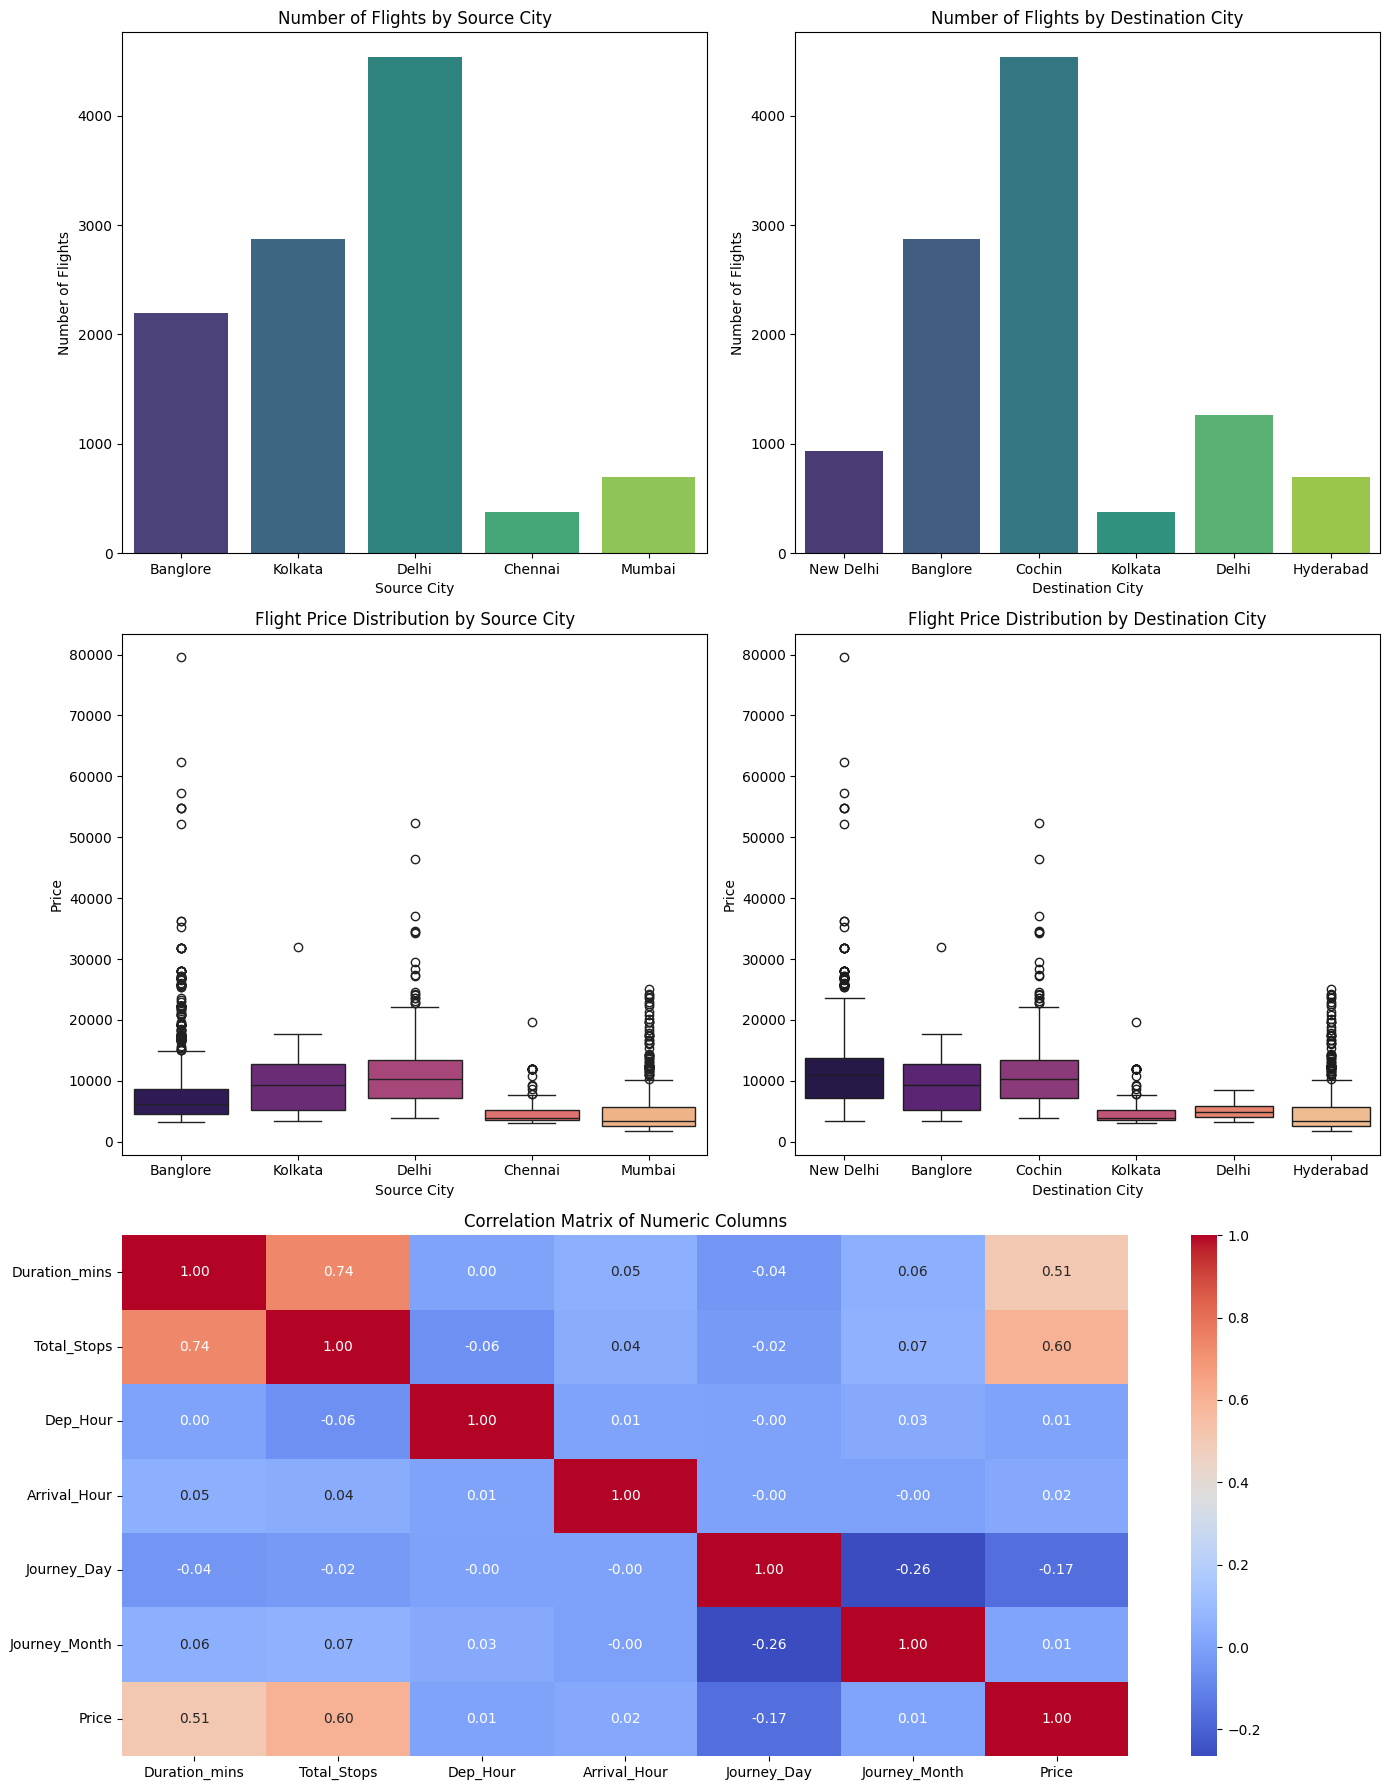

In [24]:
plt.figure(figsize=(14, 18))

# 1. Countplot of Source
plt.subplot(3, 2, 1) # 3 rows, 2 columns, first plot
sns.countplot(x='Source', data=df, palette='viridis')
plt.title('Number of Flights by Source City')
plt.xlabel('Source City')
plt.ylabel('Number of Flights')

# 2. Countplot of Destination
plt.subplot(3, 2, 2) # 3 rows, 2 columns, second plot
sns.countplot(x='Destination', data=df, palette='viridis')
plt.title('Number of Flights by Destination City')
plt.xlabel('Destination City')
plt.ylabel('Number of Flights')

# 3. Boxplot of Price vs Source
plt.subplot(3, 2, 3) # 3 rows, 2 columns, third plot
sns.boxplot(x='Source', y='Price', data=df, palette='magma')
plt.title('Flight Price Distribution by Source City')
plt.xlabel('Source City')
plt.ylabel('Price')

# 4. Boxplot of Price vs Destination
plt.subplot(3, 2, 4) # 3 rows, 2 columns, fourth plot
sns.boxplot(x='Destination', y='Price', data=df, palette='magma')
plt.title('Flight Price Distribution by Destination City')
plt.xlabel('Destination City')
plt.ylabel('Price')

# 5. Heatmap of correlation matrix of all numeric columns
plt.subplot(3, 1, 3) # 3 rows, 1 column, fifth plot (full width)
numeric_cols = ['Duration_mins', 'Total_Stops', 'Dep_Hour', 'Arrival_Hour', 'Journey_Day', 'Journey_Month', 'Price']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Columns')

plt.tight_layout()
plt.show()

### Label Encoding for Categorical Features

In [25]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Columns to be label encoded
categorical_cols = ['Airline', 'Source', 'Destination']

# Apply Label Encoding to each specified column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Label encoded column: {col}")

Label encoded column: Airline
Label encoded column: Source
Label encoded column: Destination


### DataFrame After Label Encoding: First 5 rows, Shape, and Data Types

In [26]:
display(df.head())
print(f"Shape of the DataFrame after encoding: {df.shape}")
display(df.info())

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Duration_mins,Dep_Hour,Arrival_Hour
0,3,0,5,0,3897,24,3,170,22,1
1,1,3,0,2,7662,5,1,445,5,13
2,4,2,1,2,13882,6,9,1140,9,4
3,3,3,0,1,6218,5,12,325,18,23
4,3,0,5,1,13302,3,1,285,16,21


Shape of the DataFrame after encoding: (10682, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Airline        10682 non-null  int64
 1   Source         10682 non-null  int64
 2   Destination    10682 non-null  int64
 3   Total_Stops    10682 non-null  int64
 4   Price          10682 non-null  int64
 5   Journey_Day    10682 non-null  int32
 6   Journey_Month  10682 non-null  int32
 7   Duration_mins  10682 non-null  int64
 8   Dep_Hour       10682 non-null  int32
 9   Arrival_Hour   10682 non-null  int32
dtypes: int32(4), int64(6)
memory usage: 751.1 KB


None

### Data Splitting: Training and Testing Sets

In [27]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8545, 9)
Shape of X_test: (2137, 9)
Shape of y_train: (8545,)
Shape of y_test: (2137,)


### Model Training and Evaluation

In [29]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, random_state=42)
}

# Store results
results = []

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)**0.5 # Fix: Calculate RMSE by taking the square root of MSE
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })
    print(f"{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

# Create a DataFrame from results
results_df = pd.DataFrame(results)

# Sort by R2 Score descending
results_df_sorted = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

# Display the results
print("\n--- Model Evaluation Results ---")
display(results_df_sorted)


Training Linear Regression...
Linear Regression - MAE: 2466.96, RMSE: 3501.25, R2 Score: 0.43

Training Ridge Regression...
Ridge Regression - MAE: 2466.92, RMSE: 3501.26, R2 Score: 0.43

Training Decision Tree Regressor...
Decision Tree Regressor - MAE: 1424.81, RMSE: 2698.63, R2 Score: 0.66

Training Random Forest Regressor...
Random Forest Regressor - MAE: 1274.33, RMSE: 2227.89, R2 Score: 0.77

Training XGBoost Regressor...
XGBoost Regressor - MAE: 1211.85, RMSE: 1982.90, R2 Score: 0.82

--- Model Evaluation Results ---


,Model,MAE,RMSE,R2 Score
0,XGBoost Regressor,1211.848022,1982.902859,0.817647
1,Random Forest Regressor,1274.330667,2227.888116,0.769805
2,Decision Tree Regressor,1424.806309,2698.632766,0.662248
3,Linear Regression,2466.960627,3501.253415,0.431465
4,Ridge Regression,2466.915566,3501.260655,0.431463


### 1. Outlier Removal from Price

In [30]:
import numpy as np

original_rows = df.shape[0]
df_cleaned = df[df['Price'] <= 40000]
rows_removed = original_rows - df_cleaned.shape[0]

print(f"Original number of rows: {original_rows}")
print(f"Number of rows removed (Price > 40000): {rows_removed}")
print(f"Number of rows remaining: {df_cleaned.shape[0]}")

Original number of rows: 10682
Number of rows removed (Price > 40000): 9
Number of rows remaining: 10673


### 2 & 3 & 4. Re-splitting Data and Log Transformation on Target

In [31]:
from sklearn.model_selection import train_test_split

# Redefine features (X) and target (y) with the cleaned DataFrame
X_cleaned = df_cleaned.drop('Price', axis=1)
y_cleaned = df_cleaned['Price']

# Re-split into training and testing sets
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Apply log transformation on y_train_cleaned and y_test_cleaned
y_train_log = np.log(y_train_cleaned)
y_test_log = np.log(y_test_cleaned)

print(f"Shape of X_train_cleaned: {X_train_cleaned.shape}")
print(f"Shape of X_test_cleaned: {X_test_cleaned.shape}")
print(f"Shape of y_train_log: {y_train_log.shape}")
print(f"Shape of y_test_log: {y_test_log.shape}")

Shape of X_train_cleaned: (8538, 9)
Shape of X_test_cleaned: (2135, 9)
Shape of y_train_log: (8538,)
Shape of y_test_log: (2135,)


### 5 & 6 & 7. Retrain XGBoost with Log Transformed Target and Evaluate

In [32]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Retrain XGBoost Regressor
print("\nTraining XGBoost Regressor with log-transformed target...")
xgboost_model_log = XGBRegressor(n_estimators=100, random_state=42)
xgboost_model_log.fit(X_train_cleaned, y_train_log)

# Make predictions on the log-transformed test set
y_pred_log = xgboost_model_log.predict(X_test_cleaned)

# Convert predictions back to original scale using np.exp()
y_pred_original_scale = np.exp(y_pred_log)

# Convert actual y_test_log back to original scale for metric calculation
y_test_original_scale = np.exp(y_test_log)

# Calculate metrics on original scale
mae_new = mean_absolute_error(y_test_original_scale, y_pred_original_scale)
rmse_new = mean_squared_error(y_test_original_scale, y_pred_original_scale)**0.5
r2_new = r2_score(y_test_original_scale, y_pred_original_scale)

print("\n--- New XGBoost Model Evaluation Results (after outlier removal and log transformation) ---")
print(f"New XGBoost - MAE: {mae_new:.2f}, RMSE: {rmse_new:.2f}, R2: {r2_new:.2f}")

print("\n--- Comparison ---")
print("Previous XGBoost - MAE: 1211, RMSE: 1982, R2: 0.82")
print(f"New XGBoost - MAE: {mae_new:.2f}, RMSE: {rmse_new:.2f}, R2: {r2_new:.2f}")


Training XGBoost Regressor with log-transformed target...

--- New XGBoost Model Evaluation Results (after outlier removal and log transformation) ---
New XGBoost - MAE: 1122.60, RMSE: 1609.44, R2: 0.86

--- Comparison ---
Previous XGBoost - MAE: 1211, RMSE: 1982, R2: 0.82
New XGBoost - MAE: 1122.60, RMSE: 1609.44, R2: 0.86


### Feature Importance of the Tuned XGBoost Model

/tmp/ipykernel_3460/2556926297.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')


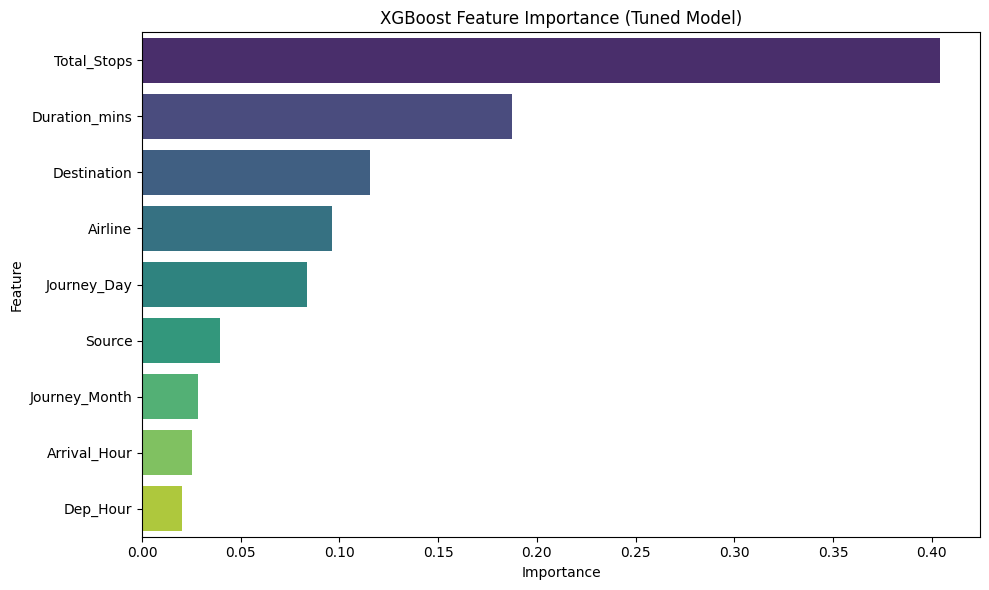

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best XGBoost model
feature_importances = best_xgb_model.feature_importances_

# Create a Series with feature names and their importances
features_df = pd.DataFrame({
    'Feature': X_train_cleaned.columns,
    'Importance': feature_importances
})

# Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')
plt.title('XGBoost Feature Importance (Tuned Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

In [36]:
import joblib

# 1. Save the model
joblib.dump(xgboost_model_log, 'flight_price_model.pkl')
print("Model saved as 'flight_price_model.pkl'")

# 2. Load the model back
loaded_model = joblib.load('flight_price_model.pkl')
print("Model loaded successfully!")

# 3. Make a sample prediction on X_test first 5 rows
sample_X_test = X_test_cleaned.head(5)
sample_y_test = y_test_cleaned.head(5)

# Predict on the log-transformed data
predicted_log_prices = loaded_model.predict(sample_X_test)

# Convert predictions back to original scale
predicted_prices = np.exp(predicted_log_prices)

# 4. Print the predicted prices
print("\nPredicted Prices (first 5 test samples):")
for i, price in enumerate(predicted_prices):
    print(f"Sample {i+1}: {price:.2f}")

# 5. Print actual prices alongside for comparison
print("\nActual Prices (first 5 test samples):")
for i, price in enumerate(sample_y_test):
    print(f"Sample {i+1}: {price:.2f}")

Model saved as 'flight_price_model.pkl'
Model loaded successfully!

Predicted Prices (first 5 test samples):
Sample 1: 5488.61
Sample 2: 4886.26
Sample 3: 6534.62
Sample 4: 10670.50
Sample 5: 4199.84

Actual Prices (first 5 test samples):
Sample 1: 7229.00
Sample 2: 5117.00
Sample 3: 5964.00
Sample 4: 10877.00
Sample 5: 4174.00


In [38]:
print(type(loaded_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [39]:
# Save the cleaned DataFrame to a CSV file
df_cleaned.to_csv('cleaned_flight_price_data.csv', index=False)
print("Cleaned DataFrame saved as 'cleaned_flight_price_data.csv'")

Cleaned DataFrame saved as 'cleaned_flight_price_data.csv'


You can download the files to your local machine by running the following cells:

In [40]:
from google.colab import files

# Download the model
files.download('flight_price_model.pkl')

# Download the cleaned dataset
files.download('cleaned_flight_price_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>